In [ ]:
%reset -f
from main import cost_func, aero_cost
import pygad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
def fitness_func(ga_instance, solution, solution_idx):
    fitness = aero_cost(solution[0], solution[1], solution[2], solution[3], solution[4], solution[5])
    return fitness

In [ ]:
# population_history = []

def on_gen(ga_instance):

    # solution, fitness, idx = ga_instance.best_solution()
    # population_history.append(ga_instance.population.copy())

    if ga_instance.generations_completed % 5 == 0:
        solution, fitness, _ = ga_instance.best_solution()

        print(f"Gen {ga_instance.generations_completed} | Best Fitness = {fitness}")
        print("Design Variables:")
        print(f"Wingspan: {solution[0]}")
        print(f"Mid chord: {solution[1]}")
        print(f"Tip chord: {solution[2]}")
        print(f"Root twist: {solution[3]}")
        print(f"Mid twist: {solution[4]}")
        print(f"Tip twist: {solution[5]}")

In [ ]:
gene_space = [
    {'low':0.3, 'high':20}, # wingspan
    {'low':0.1, 'high':0.15}, # mid chord
    {'low':0.05, 'high':0.1}, # tip chord
    {'low':-5, 'high':0}, # root twist
    {'low':-5, 'high':0}, # mid twist
    {'low':-5, 'high':0} # tip twist
]

gene_type = [
    float, # wingspan
    float, # mid chord
    float, # tip chord
    float, # root twist
    float, # mid twist
    float # tip twist
]

init_pop = [
    [5.00, 0.15, 0.15, 0, 0, 0],
    # [4.29, 0.115, 0.048, -3.19, -1.399, -1.58],
    [4.3, 0.1, 0.04, -3.1, -1.4, -1.5],
    [4.4, 0.1, 0.05, -3, -1, -2],
    [3.31, 0.13, 0.05, -2.25, -1.4, -0.3],
    [8.00, 0.15, 0.15, 0, -2, -3],
    [4.00, 0.10, 0.08, -3.0, -2.0, 0],
    [10.0, 0.15, 0.15, -5, -3, -1],
    [1.00, 0.12, 0.08, 0, 0, 0],
    [18.0, 0.15, 0.15, 0, 0, 0],
    [6.2, 0.14, 0.08, -4, -2, -3],
    [7.4, 0.10, 0.05, -3, -2, -1],
    # [9.00, 0.11, 0.10, 0, 0, 0]
]

# init_pop = [
#     [5.00, 0.15, 0.15, 0, 0, 0],
#     [4.29, 0.115, 0.048, -3.19, -1.399, -1.58],
#     [4.4, 0.1, 0.05, -3, -1, -2],
#     [3.31, 0.13, 0.05, -2.25, -1.4, -0.3],
# ]

# gene_df = pd.DataFrame(gene_space)

# random_init_pop = np.random.uniform(gene_df['low'], gene_df['high'], size=(60-len(init_pop), len(func_inputs)))

# initial_pop = np.vstack((init_pop, random_init_pop))

ga_inst = pygad.GA(num_generations=100, # number of generations run
                  num_parents_mating=10, # how many of best solutions are selected to be parents in the next, roughly half of or less than half of sol_per_pop
                  sol_per_pop=60, # each population has this many solutions, only meaningful if initial_population is not used, small value might prevent finding high-quality solutions, large value might lead to unnecessary computational expense
                  keep_parents=2, # contols elitism, how many parents from current generation are carried to the next, typically 1 or 2
                  num_genes=6, # each solution has this many genes with constraints set by gene_space
                  fitness_func=fitness_func,
                #   initial_population=init_pop,
                  parent_selection_type="tournament",
                  K_tournament=3,
                  crossover_type="uniform",
                  mutation_type="random",
                  mutation_percent_genes=25, # increased from 25
                #   mutation_type="adaptive",
                #   mutation_percent_genes=[30,5],
                  gene_space=gene_space, # use instead of init_range_low/high, constraints to genes
                  gene_type=gene_type, # value type for genes
                  on_generation=on_gen)

ga_inst.run()

# try with existing or known result

In [ ]:
plt.plot(ga_inst.best_solutions_fitness)
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("GA Convergence")
plt.show()

In [ ]:
# solution, fitness, _ = ga_inst.best_solution()

In [ ]:
ga_inst.save(filename="test_numparents_20.pkl")

In [ ]:
# population_history = np.array(population_history)

In [ ]:
import pygad
import numpy

function_inputs = [4,-2,3.5,5,-11,-4.7] # Function inputs.
desired_output = 69 # Function output.

def fitness_func(ga_instance, solution, solution_idx):
    output = solution**2
    fitness = 1.0 / (numpy.abs(output - desired_output) + 0.000001)
    return fitness

num_generations = 100 # Number of generations.
num_parents_mating = 10 # Number of solutions to be selected as parents in the mating pool.

sol_per_pop = 100 # Number of solutions in the population.
num_genes = 1

last_fitness = 0
def on_generation(ga_instance):
    global last_fitness
    print(f"Generation = {ga_instance.generations_completed}")
    print(f"Fitness    = {ga_instance.best_solution(pop_fitness=ga_instance.last_generation_fitness)[1]}")
    print(f"Change     = {ga_instance.best_solution(pop_fitness=ga_instance.last_generation_fitness)[1] - last_fitness}")
    last_fitness = ga_instance.best_solution(pop_fitness=ga_instance.last_generation_fitness)[1]

ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       sol_per_pop=sol_per_pop,
                       num_genes=num_genes,
                       fitness_func=fitness_func,
                       on_generation=on_generation)

# Running the GA to optimize the parameters of the function.
ga_instance.run()

ga_instance.plot_fitness()

# Returning the details of the best solution.
solution, solution_fitness, solution_idx = ga_instance.best_solution(ga_instance.last_generation_fitness)
print(f"Parameters of the best solution : {solution}")
print(f"Fitness value of the best solution = {solution_fitness}")
print(f"Index of the best solution : {solution_idx}")

prediction = solution**2
print(f"Predicted output based on the best solution : {prediction}")

if ga_instance.best_solution_generation != -1:
    print(f"Best fitness value reached after {ga_instance.best_solution_generation} generations.")


In [ ]:
plt.plot(ga_instance.best_solutions_fitness)
plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("GA Convergence")
plt.show()

In [ ]:
%reset -f
import numpy as np
from scipy.optimize import minimize, Bounds
from main import aero_gradient_cost
import matplotlib.pyplot as plt


wingspan = 4 # 1 m
mid_chord = 0.1 # 15 cm
tip_chord = 0.05 # 15 cm
flange_width = 0.15*0.05
flange_thickness = 0.001
web_thickness = 0.001
t_skin = 0.001 # 1 mm
root_twist = -3 # 0 deg
mid_twist = -2 # 0 deg
tip_twist = -1 # 0 deg
skin_mat = 0
spar_mat = 0

func_inputs = [wingspan, mid_chord, tip_chord, root_twist, mid_twist, tip_twist]

history_x = []
history_cost = []

def zero_hessian(x):
    n = len(x)
    return np.zeros((n, n))

def aero_func(x):
    cost = aero_gradient_cost(x[0],x[1],x[2],x[3],x[4],x[5])
    return cost

def callback(xk, state):
    history_x.append(xk.copy())           # store current design vector
    history_cost.append(aero_func(xk))    # store current cost

bounds = Bounds(
    [0.3, 0.1, 0.05, -5, -5, -5],   # lower bounds
    [10, 0.15, 0.1, 0, 0, 0]        # upper bounds
)

res = minimize(aero_func, func_inputs,
               method='trust-constr',
               bounds=bounds,
               callback=callback,
               options={'verbose':1, 'gtol':1e-10})

history_x = np.array(history_x)  # shape: (iterations, n_variables)
history_cost = np.array(history_cost)

In [ ]:
labels = ['Span','Mid Chord','Tip Chord','Root Twist','Mid Twist','Tip Twist']
iterations = np.arange(history_x.shape[0])

plt.figure(figsize=(10,6))
for i in range(history_x.shape[1]):
    plt.plot(iterations, history_x[:, i], marker='o', label=labels[i])

plt.xlabel("Iteration")
plt.ylabel("Design Variable Value")
plt.title("Design Variable Evolution During Optimization")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(1/history_cost, marker='o')

plt.xlabel("Iteration")
plt.ylabel("Range")
# plt.title("Design Variable Evolution During Optimization")
# plt.legend()
plt.grid(True)
plt.show()

## Test of Functions

In [1]:
from main import range_km, aero_cost
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
perf_output_path = r"C:/Users/mayar/Documents/Ryerson/AALOFT/Freewake(in_use)/output/Performance.txt"
df_performance = pd.read_csv(perf_output_path, sep=r'\s+', skiprows=3)

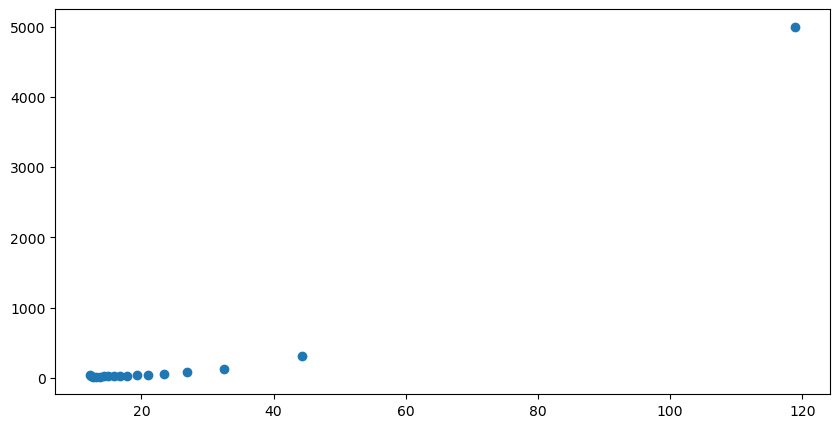

In [3]:
fig, ax1 = plt.subplots(1,1,figsize=(10,5))

ax1.scatter(df_performance.Vinf, df_performance.Preq)

plt.show()

In [ ]:
from main import power_eqn, curve_fit
from scipy.interpolate import interp1d

df_clean = df_performance.dropna()
coefficients, _ = curve_fit(power_eqn, df_clean['Vinf'], df_clean['Preq'])
a_fit, b_fit, c_fit = coefficients



In [ ]:
# Find speed for max range
V_maxR = np.sqrt(c_fit/a_fit)

# Find power required at speed for max range
Preq = power_eqn(V_maxR, a_fit, b_fit, c_fit)



In [ ]:
f_aoa_max = interp1d(df_clean['Vinf'],df_clean['alpha'],kind='linear')
try:
    aoa_maxR = f_aoa_max(V_maxR)
except ValueError:
    aoa_maxR = f_aoa_max(min(df_clean['Vinf']))

In [ ]:
range_est = range_km(V_maxR, Preq)

In [ ]:
costing = aero_cost(1.6343257682672812, 0.12297741931125451, 0.010094425029942192, -0.6173476290335778, -1.4290289849194049, -3.8638424345846314)

In [ ]:
range_est = range_km(44.54, 77.84)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from Mass import spar_vol, spar_area, spar_y_area, get_density, struct_vol
import materials
from main import aero
import os
import shutil

wingspan = 3.31 # 1 m
mid_chord = 0.13 # 15 cm
tip_chord = 0.05 # 15 cm
w_flange = 0.15*0.005
t_flange = 0.00001
t_web = 0.00001
t_skin_root = 0.00001 # 1 mm
t_skin_mid = 0.00001
t_skin_tip = 0.00001
mid_twist = -1.4 # 0 deg
tip_twist = -0.3 # 0 deg
skin_index = 0
spar_index = 0

V_maxR, Preq, y_pos, y_load = aero(5, wingspan, mid_chord, tip_chord, mid_twist, tip_twist, 0, 0)

